# This notebook is intended to evaluate the Runge effect on a function's approximation using Lagrange Polynomials

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

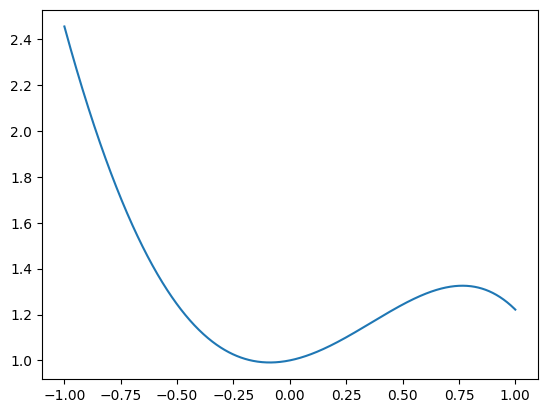

In [ ]:
# Function to approximate
def f(x):
    return 1/(1+25*x**2)

def g(x):
    return np.sin(5*np.pi*x)

def h(x):
    return (1 + x**2 - x**3)*np.exp(x/5)

func = h
X = np.linspace(-1, 1, 1000)
plt.plot(X, func(X))

In [ ]:
class LagrangianBasisVector():
    def __init__(self, X, k):
        self.x_k = X[k]
        self.X_j = np.delete(X, k)

    def evaluate(self, x):
        return np.array([np.prod(x_k-self.X_j)/np.prod(self.x_k-self.X_j) for x_k in x])
    
class LagrangianFunctionApprox():
    def __init__(self, func, X):
        self.func = func
        self.X = X
        nb_points = X.shape[0]
        print(X.shape)
        self.basis_vectors = [LagrangianBasisVector(X, i) for i in range(nb_points)]

    def evaluate(self, x_eval):
        result = 0
        for (i, x_i) in enumerate(self.X):
            result += self.func(x_i) * self.basis_vectors[i].evaluate(x_eval)
        return result
        

In [ ]:
k = 20


In [ ]:
# Approximation by uniform x distribution :
X_unif_approx = np.linspace(-1, 1, k)
X_tchebychev_approx = np.cos(np.array([(2*i-1)*np.pi/(2*k) for i in range(1, k+1)]))
unif_approx = LagrangianFunctionApprox(func, X_unif_approx)
tchebychev_approx = LagrangianFunctionApprox(func, X_tchebychev_approx)

(20,)
(20,)


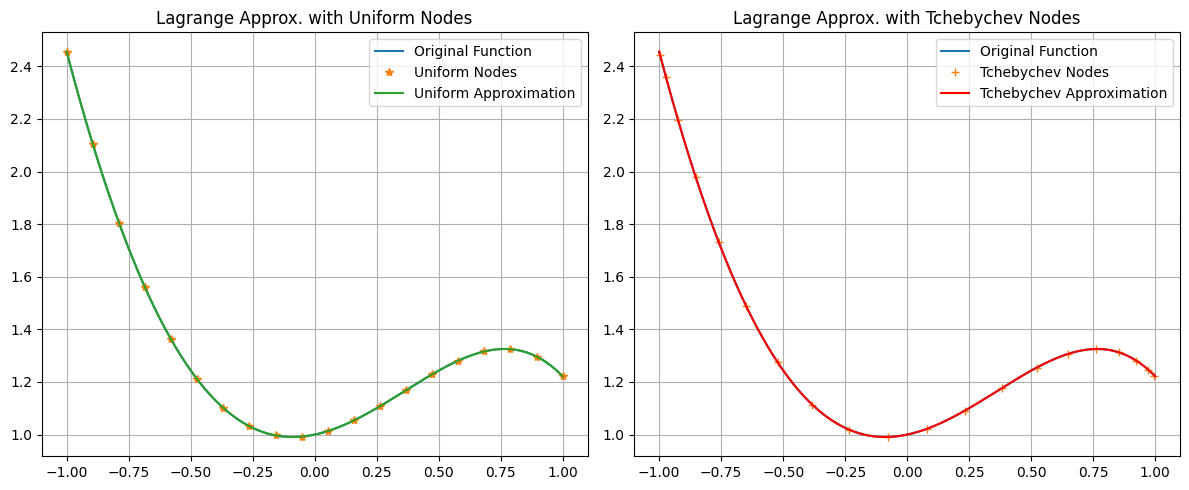

In [ ]:
# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Uniform approximation
axs[0].plot(X, func(X), label='Original Function')
axs[0].plot(X_unif_approx, func(X_unif_approx), '*', label='Uniform Nodes')
axs[0].plot(X, unif_approx.evaluate(X), label='Uniform Approximation')
axs[0].set_title('Lagrange Approx. with Uniform Nodes')
axs[0].legend()
axs[0].grid(True)

# Second subplot: Tchebychev approximation
axs[1].plot(X, func(X), label='Original Function')
axs[1].plot(X_tchebychev_approx, func(X_tchebychev_approx), '+', label='Tchebychev Nodes')
axs[1].plot(X, tchebychev_approx.evaluate(X), color='red', label='Tchebychev Approximation')
axs[1].set_title('Lagrange Approx. with Tchebychev Nodes')
axs[1].legend()
axs[1].grid(True)

# Display plots
plt.tight_layout()
plt.show()

In [ ]:
class Polynomial():
    def __init__(self, coefficients : np.ndarray):
        self.coefficients = coefficients
        self.degree = coefficients.size-1
        # if coefficients == np.array([0]):
        #     self.degree = - np.inf

    def erase_end_zeros(self):
        d = self.coefficients.size-1
        while self.coefficients[d]==0:
            d-=1
        self.coefficients = self.coefficients[:d+1]
        return self
    
    def __add__(self, other):
        max_degree = max(self.degree, other.degree)
        adapted_coeff_other = np.concatenate((other.coefficients, np.zeros(max_degree - other.degree)))
        adapted_coeff_self =np.concatenate((self.coefficients, np.zeros(max_degree - self.degree)))
        return Polynomial(np.array(adapted_coeff_other + adapted_coeff_self)).erase_end_zeros()
    
    def __sub__(self, other):
        return self + other.scalar_mult(-1)
    
    def convolution(self, other, n):
        # Computes the convolution of other.coefficients and self.coefficients at X^n
        result = 0
        for k in range(self.degree+1):
            if n-k >= other.degree+1 or k>n:
                continue
            result += self.coefficients[k]*other.coefficients[n-k]
        return result
    
    def __str__(self, round_num=2):
        string = f"{self.coefficients[0]}"
        for i, coeff in enumerate(self.coefficients):
            string += f" + {round(coeff, round_num)} X^{i}"
        return string
    
    def __mul__(self, other):
        return Polynomial(
            np.array(
                [self.convolution(other, n) for n in range(self.degree+other.degree+1)]
                )
                          )
    
    def __call__(self, x:np.ndarray):
        # Creating a x^i vector
        x_i = np.array([x**i for i in range(self.degree+1)])
        return np.dot(self.coefficients, x_i)
    
    def scalar_mult(self, a):
        new_coeff = a*self.coefficients
        return Polynomial(new_coeff)

    
class Monomial(Polynomial):
    def __init__(self, degree):
        coeffs = np.array([0 for _ in range(degree)] + [1])
        super().__init__(coeffs)

In [ ]:
def lagrange_basis(x:list):
    L_basis = []
    for j, x_j in enumerate(x):
        L_i = Polynomial(np.ones(1))
        for i, x_i in enumerate(x):
            if i==j:
                continue
            L_i *= Polynomial(np.array([-x_i, 1])).scalar_mult((x_j-x_i)**(-1))
        L_basis.append(L_i)
    return L_basis

def lagrange_interpolation_polynomial(func, x):
    basis = lagrange_basis(x)
    interpolation_polynomial = Polynomial(np.zeros(1))
    for i, x_i in enumerate(x): 
        interpolation_polynomial += basis[i].scalar_mult(func(x_i))
    return interpolation_polynomial


In [ ]:
P = Polynomial(np.array([-1, 1, 2])) # -1 + X + 2X^2*
Q = Polynomial(np.array([1, 0, 2])) # 1 + X^2
R = Polynomial(np.array([1, 0, 1, 3, 4])) # 1 + X^2 + 3X^3 + 4X^4
print((P-Q).coefficients)

X_four = Monomial(4)
print(X_four.degree)
print((P*R).coefficients)

print(P(5))

interpolation = lagrange_interpolation_polynomial(f, [0, 1, 2, 3])
print(interpolation)
print(f(0)-interpolation(0), f(1)-interpolation(1), f(2)-interpolation(2), f(3)-interpolation(3))

[-2.  1.]
4
[-1  1  1 -2  1 10  8]
54
1.0 + 1.0 X^0 + -1.73 X^1 + 0.92 X^2 + -0.15 X^3
0.0 -1.6653345369377348e-16 -6.74807432154978e-16 -1.4779844015322396e-15


In [ ]:
print(interpolation(np.array([1, 2])))
print(f(np.array([1, 2])))

[0.03846154 0.00990099]
[0.03846154 0.00990099]


In [ ]:
uniform_interpolation = lagrange_interpolation_polynomial(func, X_unif_approx)
tchebychev_interpolation = lagrange_interpolation_polynomial(func, X_tchebychev_approx)

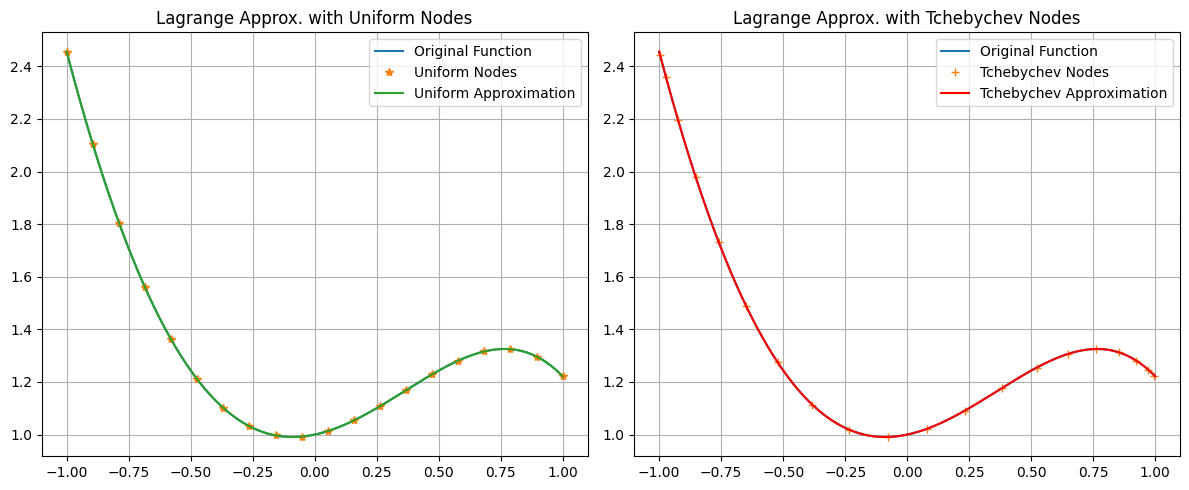

In [ ]:
# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Uniform approximation
axs[0].plot(X, func(X), label='Original Function')
axs[0].plot(X_unif_approx, func(X_unif_approx), '*', label='Uniform Nodes')
axs[0].plot(X, uniform_interpolation(X), label='Uniform Approximation')
axs[0].set_title('Lagrange Approx. with Uniform Nodes')
axs[0].legend()
axs[0].grid(True)

# Second subplot: Tchebychev approximation
axs[1].plot(X, func(X), label='Original Function')
axs[1].plot(X_tchebychev_approx, func(X_tchebychev_approx), '+', label='Tchebychev Nodes')
axs[1].plot(X, tchebychev_interpolation(X), color='red', label='Tchebychev Approximation')
axs[1].set_title('Lagrange Approx. with Tchebychev Nodes')
axs[1].legend()
axs[1].grid(True)

# Display plots
plt.tight_layout()
plt.show()

In [ ]:
# Generating the n first Tchebychev polynomials for n greater or equal to 1
def generate_tchebychev(n):
    T_zero = Polynomial(np.array([1]))
    T_one = Polynomial(np.array([0, 1]))
    T = [T_zero, T_one]
    for i in range(n-1):
        T_i = Polynomial(np.array([0, 2]))*T[-1] - T[-2]
        T.append(T_i)
    return T

def change_of_basis_matrix(n):
    T = generate_tchebychev(n)
    return np.column_stack(
        [np.concatenate((tche.coefficients, np.zeros(n-i))) for i, tche in enumerate(T)]
        )
    

In [ ]:
tchebychev_polynomials = generate_tchebychev(3)
print(np.column_stack([np.concatenate((tche.coefficients, np.zeros(3-i))) for i, tche in enumerate(tchebychev_polynomials)]))

[[ 1.  0. -1.  0.]
 [ 0.  1.  0. -3.]
 [ 0.  0.  2.  0.]
 [ 0.  0.  0.  4.]]


In [ ]:
# Generating spectral coefficients
coeffs = tchebychev_interpolation.coefficients
vec_new = np.linalg.solve(change_of_basis_matrix(tchebychev_interpolation.degree), coeffs)

In [ ]:
print(vec_new)

[ 1.44212849e+00 -4.10700047e-01  4.19438491e-01 -2.05520199e-01
 -2.27297178e-02 -1.17351421e-03 -3.97433963e-05 -1.00388472e-06
 -2.06607042e-08 -5.63186761e-10 -9.95256377e-11 -3.44743262e-11
 -1.01877395e-11 -2.37635259e-12 -2.99933689e-13  1.85025606e-14
  2.51881849e-14  6.15132945e-15  1.32532874e-15 -2.25514052e-16]


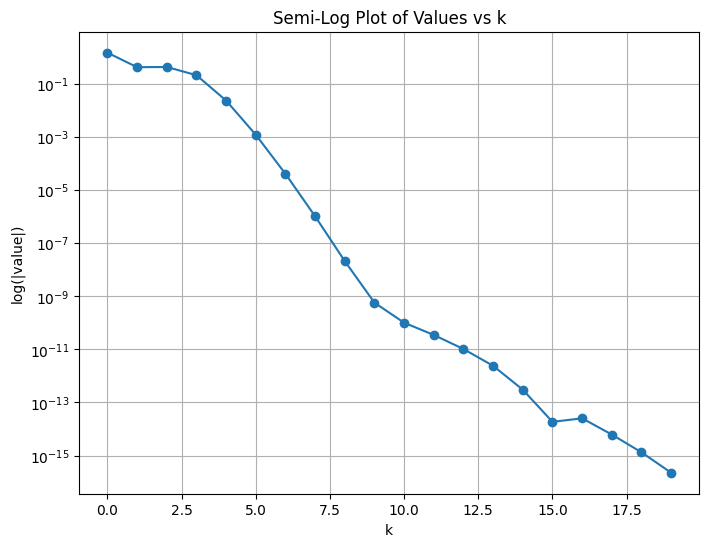

In [ ]:
k = np.arange(len(vec_new))  # x-axis: k = 0, 1, 2, ..., 29

# Plot
plt.figure(figsize=(8,6))
plt.semilogy(k, np.abs(vec_new), marker='o')  # abs to avoid log of negative values
plt.xlabel('k')
plt.ylabel('log(|value|)')
plt.title('Semi-Log Plot of Values vs k')
plt.grid(True, which='both')
plt.show()